In [3]:
!pip install numpy pandas matplotlib scikit-learn
!pip install torch torchvision torchaudio
!pip install seaborn jupyterlab


   ------------- -------------------------- 2/6 [lark]
   --------------------------------- ------ 5/6 [isoduration]
   ---------------------------------------- 6/6 [isoduration]



In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import seaborn as sns
from sklearn.metrics import mean_squared_error

In [25]:
df = pd.read_csv("D:\Sema\StockPrice\AMZN_2006-01-01_to_2018-01-01.csv")
df.head()

,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,47.47,47.85,46.25,47.58,7582127,AMZN
1,2006-01-04,47.48,47.73,46.69,47.25,7440914,AMZN
2,2006-01-05,47.16,48.20,47.11,47.65,5417258,AMZN
3,2006-01-06,47.97,48.58,47.32,47.87,6154285,AMZN
4,2006-01-09,46.55,47.10,46.40,47.08,8945056,AMZN


In [26]:
scaler = MinMaxScaler(feature_range=(-1,1))
close_data = scaler.fit_transform(df['Close'].values.reshape(-1,1))

In [27]:
lookback = 20
X, y = [], []

for i in range(len(close_data) - lookback):
    X.append(close_data[i:i+lookback])
    y.append(close_data[i+lookback])

X = np.array(X)
y = np.array(y)

In [28]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [29]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, output_size=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

model = LSTMModel()

In [30]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):  # küçük test için 10 epoch
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")
print("done")

Epoch 1, Loss: 0.0079
Epoch 2, Loss: 0.0003
Epoch 3, Loss: 0.0008
Epoch 4, Loss: 0.0007
Epoch 5, Loss: 0.0006
Epoch 6, Loss: 0.0004
Epoch 7, Loss: 0.0002
Epoch 8, Loss: 0.0003
Epoch 9, Loss: 0.0004
Epoch 10, Loss: 0.0005
done


In [31]:
model.eval()
with torch.no_grad():
    predictions = model(X_tensor).numpy()

predicted_prices = scaler.inverse_transform(predictions)
actual_prices = scaler.inverse_transform(y_tensor.numpy())

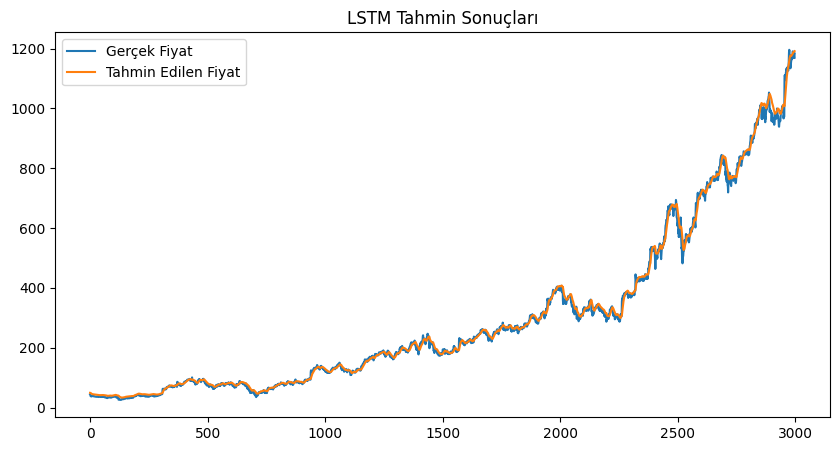

In [32]:
plt.figure(figsize=(10,5))
plt.plot(actual_prices, label="Gerçek Fiyat")
plt.plot(predicted_prices, label="Tahmin Edilen Fiyat")
plt.legend()
plt.title("LSTM Tahmin Sonuçları")
plt.show()

In [37]:
gru_model = GRUModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(gru_model.parameters(), lr=0.001)

for epoch in range(10):
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        output = gru_model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")
print("done")

Epoch 1, Loss: 0.0008
Epoch 2, Loss: 0.0006
Epoch 3, Loss: 0.0006
Epoch 4, Loss: 0.0005
Epoch 5, Loss: 0.0002
Epoch 6, Loss: 0.0001
Epoch 7, Loss: 0.0004
Epoch 8, Loss: 0.0002
Epoch 9, Loss: 0.0003
Epoch 10, Loss: 0.0001
done


In [38]:
gru_model.eval()
with torch.no_grad():
    gru_predictions = gru_model(X_tensor).numpy()

gru_predicted_prices = scaler.inverse_transform(gru_predictions)

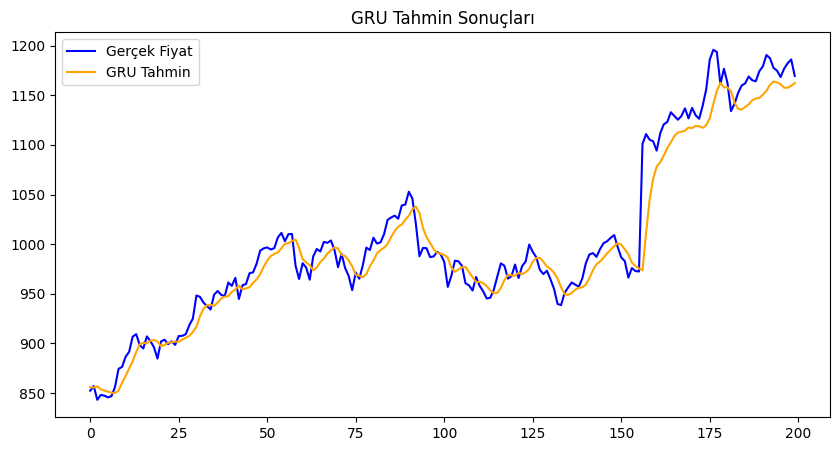

In [39]:
plt.figure(figsize=(10,5))
plt.plot(actual_prices[-200:], label="Gerçek Fiyat", color="blue")
plt.plot(gru_predicted_prices[-200:], label="GRU Tahmin", color="orange")
plt.legend()
plt.title("GRU Tahmin Sonuçları")
plt.show()

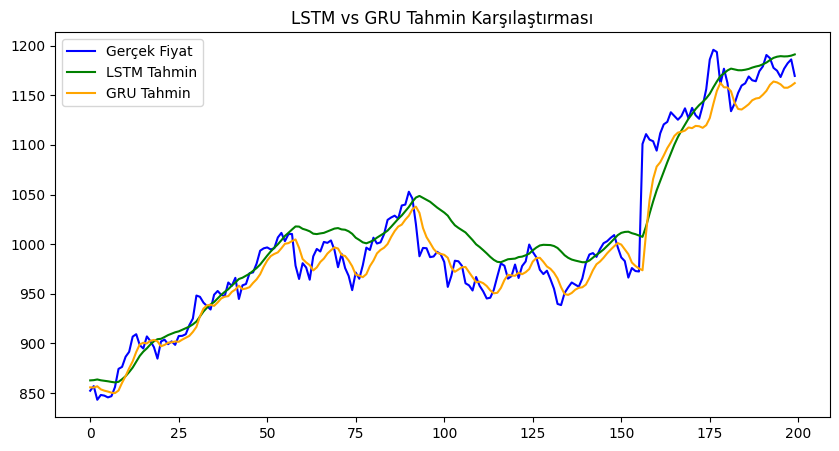

In [40]:
plt.figure(figsize=(10,5))
plt.plot(actual_prices[-200:], label="Gerçek Fiyat", color="blue")
plt.plot(predicted_prices[-200:], label="LSTM Tahmin", color="green")
plt.plot(gru_predicted_prices[-200:], label="GRU Tahmin", color="orange")
plt.legend()
plt.title("LSTM vs GRU Tahmin Karşılaştırması")
plt.show()

In [41]:
mse_lstm = mean_squared_error(actual_prices, predicted_prices)
mse_gru = mean_squared_error(actual_prices, gru_predicted_prices)

print("LSTM MSE:", mse_lstm)
print("GRU MSE:", mse_gru)

LSTM MSE: 169.17079162597656
GRU MSE: 95.16558837890625
